tol = 0.001
  Jacobi      : iterations =    4, x = [ 3.0000225  -2.50000266  6.99998104]
  Gauss-Seidel: iterations =    4, x = [ 3.00000035 -2.50000004  6.99999999]



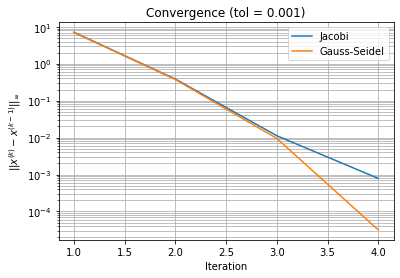

tol = 1e-06
  Jacobi      : iterations =    7, x = [ 3.  -2.5  7. ]
  Gauss-Seidel: iterations =    5, x = [ 3.  -2.5  7. ]



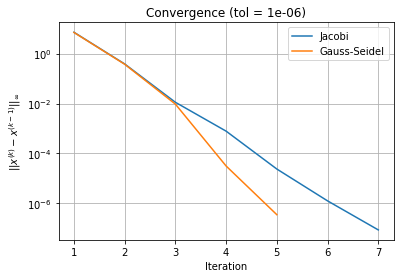

tol = 1e-09
  Jacobi      : iterations =    9, x = [ 3.  -2.5  7. ]
  Gauss-Seidel: iterations =    7, x = [ 3.  -2.5  7. ]



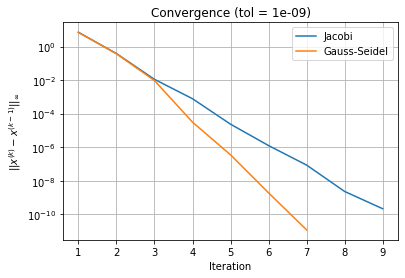

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# System Ax = b
A = np.array([
    [3.0, -0.1, -0.2],
    [0.1, 7.0, -0.3],
    [0.3, -0.2, 10.0]
])
b = np.array([7.85, -19.3, 71.4])

x0 = np.zeros(3)
tols = [1e-3, 1e-6, 1e-9]
max_iter = 10000

#jacobi
def jacobi(A, b, x0, tol, max_iter):
    D = np.diag(A)
    R = A - np.diagflat(D)

    x = x0.astype(float).copy()
    errors = []

    for k in range(max_iter):
        x_new = (b - R @ x) / D
        err = np.linalg.norm(x_new - x, ord=np.inf)   # absolute error between iterations
        errors.append(err)

        if err < tol:
            return x_new, k + 1, np.array(errors)

        x = x_new

    return x, max_iter, np.array(errors)

#gauss_seidel
def gauss_seidel(A, b, x0, tol, max_iter):
    n = len(b)
    x = x0.astype(float).copy()
    errors = []

    for k in range(max_iter):
        x_old = x.copy()

        for i in range(n):
            s1 = A[i, :i] @ x[:i]              # newest values
            s2 = A[i, i+1:] @ x_old[i+1:]      # old values
            x[i] = (b[i] - s1 - s2) / A[i, i]

        err = np.linalg.norm(x - x_old, ord=np.inf)    # absolute error between iterations
        errors.append(err)

        if err < tol:
            return x, k + 1, np.array(errors)

    return x, max_iter, np.array(errors)


# run and compareeee yipee
for tol in tols:
    xJ, itJ, errJ = jacobi(A, b, x0, tol, max_iter)
    xG, itG, errG = gauss_seidel(A, b, x0, tol, max_iter)

    print(f"tol = {tol:g}")
    print(f"  Jacobi      : iterations = {itJ:>4}, x = {xJ}")
    print(f"  Gauss-Seidel: iterations = {itG:>4}, x = {xG}")
    print()

    # Plot convergence (absolute error between iterations)
    # made it super fancy this time
    plt.figure()
    plt.semilogy(range(1, len(errJ) + 1), errJ, label="Jacobi")
    plt.semilogy(range(1, len(errG) + 1), errG, label="Gauss-Seidel")
    plt.xlabel("Iteration")
    plt.ylabel(r"$||x^{(k)} - x^{(k-1)}||_\infty$")
    plt.title(f"Convergence (tol = {tol:g})")
    plt.legend()
    plt.grid(True, which="both")
    plt.show()
    

From the results, both methods converge to the same solution, but Gauss–Seidel consistently converges faster than Jacobi. This happens because Gauss–Seidel updates and immediately uses the newest values of x within the same iteration, while Jacobi waits until the next iteration to use updated values. Because of this, Gauss–Seidel reduces the error more quickly per iteration, which is why it requires fewer iterations to reach the same tolerance.

As the tolerance becomes smaller (from 10^-3 to 10^-6 to 10^-9), the number of iterations required for convergence increases for both methods. A smaller tolerance means we are demanding a more accurate solution, so the algorithm has to keep iterating until the difference between successive iterations is very small. This trend is visible in the error plots, where tighter tolerances push convergence further out along the iteration axis. Even as the tolerance decreases, Gauss–Seidel still converges faster than Jacobi, showing that it is the more efficient method for this system.

Reference internet and chatgpt for help with the plotting. Prompt: How to plot the two lines where i can see the convergence. (plt.semilogy). it explained why we plot the log because the error gets really small really fast and this would allow me to see the convergence more clearly.